# Exercise 1: A low-pass filter



$$\frac{dV_{out}}{dt} = \frac{1}{RC} (V_{in} - V_{out})$$

a)

$$
V_{in}(t) = \cases{1 \,\, \text{if is \(\lfloor 2t \rfloor\) even},\\
                   -1 \,\, \text{if is \(\lfloor 2t \rfloor\) odd}
}
$$

for t = 0 to t = 10

RC = 0.01, 0.1, 1

Initial Condition: $V_{out} (0) = 0$

RK4 method:
\begin{aligned}
x(t+h) &= x(t) + \frac{1}{6}(k_1 + 2k_2 + 2k_3 + k_4) \\
k_1 &= h f(t, x), \\
k_2 &= h f\left(t + \frac{h}{2}, x + \frac{k_1}{2}\right), \\
k_3 &= h f\left(t + \frac{h}{2}, x + \frac{k_2}{2}\right), \\
k_4 &= h f(t + h, x + k_3)
\end{aligned}



In [ ]:
## V_{in}
def Vin(t):
  if np.floor(2*t) % 2 == 0:
      return 1
  else:
      return -1

In [ ]:
## f(x,t)
def f(t, V, RC):
  return (1/RC)*(Vin(t) - V)

In [ ]:
## RK4 solver
def RK4(RC, h=0.001, t_max=10):
  t_vals = np.arange(0, t_max, h)
  Vout_vals = np.zeros(len(t_vals))

  V = 0  # initial condition

  for i, t in enumerate(t_vals):
    Vout_vals[i] = V

    k1 = f(t, V, RC)
    k2 = f(t + h/2, V + h*k1/2, RC)
    k3 = f(t + h/2, V + h*k2/2, RC)
    k4 = f(t + h, V + h*k3, RC)

    V += (h/6)*(k1 + 2*k2 + 2*k3 + k4)

  return t_vals, Vout_vals

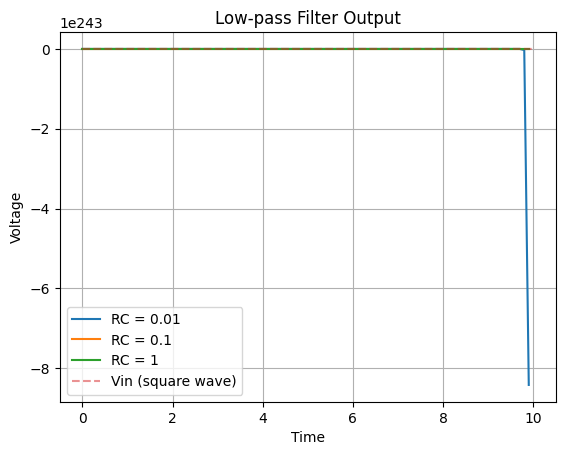

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# h = 0.1

RC_values = [0.01, 0.1 , 1]

for RC in RC_values:
  t, Vout = RK4(RC, h =0.1)
  plt.plot(t, Vout, label=f"RC = {RC}")


t = np.arange(0, 10, 0.001)
Vin_vals = [Vin(tt) for tt in t]
plt.plot(t, Vin_vals, '--', label="Vin (square wave)", alpha=0.5)

plt.xlabel("Time")
plt.ylabel("Voltage")
plt.legend()
plt.title("Low-pass Filter Output")
plt.grid()
plt.show()

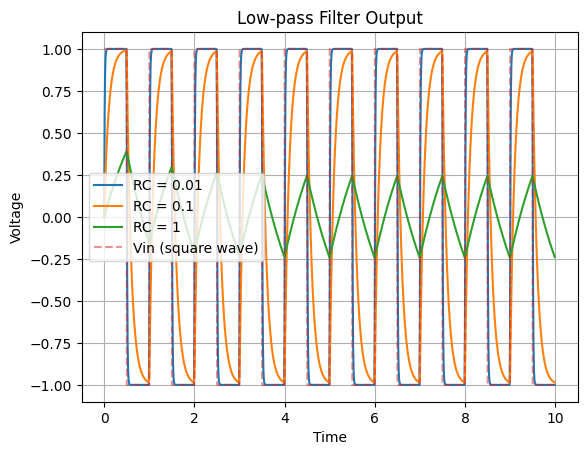

In [ ]:
# h = 0.01

RC_values = [0.01, 0.1 , 1]

for RC in RC_values:
  t, Vout = RK4(RC, 0.01)
  plt.plot(t, Vout, label=f"RC = {RC}")


t = np.arange(0, 10, 0.001)
Vin_vals = [Vin(tt) for tt in t]
plt.plot(t, Vin_vals, '--', label="Vin (square wave)", alpha=0.5)

plt.xlabel("Time")
plt.ylabel("Voltage")
plt.legend()
plt.title("Low-pass Filter Output")
plt.grid()
plt.show()

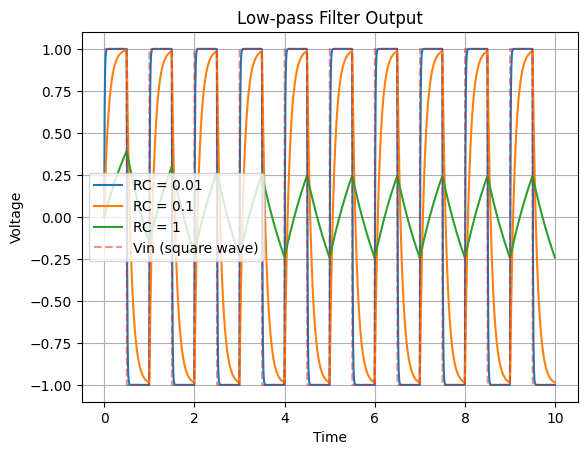

In [ ]:
# h = 0.005

RC_values = [0.01, 0.1 , 1]

for RC in RC_values:
  t, Vout = RK4(RC, h = 0.005)
  plt.plot(t, Vout, label=f"RC = {RC}")


t = np.arange(0, 10, 0.001)
Vin_vals = [Vin(tt) for tt in t]
plt.plot(t, Vin_vals, '--', label="Vin (square wave)", alpha=0.5)

plt.xlabel("Time")
plt.ylabel("Voltage")
plt.legend()
plt.title("Low-pass Filter Output")
plt.grid()
plt.show()

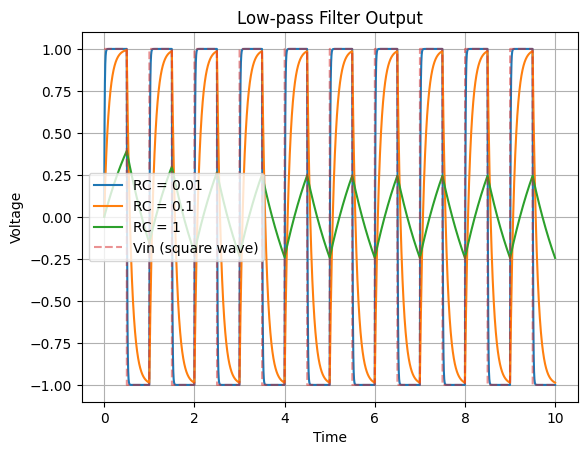

In [ ]:
# h = 0.001

RC_values = [0.01, 0.1 , 1]

for RC in RC_values:
  t, Vout = RK4(RC)
  plt.plot(t, Vout, label=f"RC = {RC}")


t = np.arange(0, 10, 0.001)
Vin_vals = [Vin(tt) for tt in t]
plt.plot(t, Vin_vals, '--', label="Vin (square wave)", alpha=0.5)

plt.xlabel("Time")
plt.ylabel("Voltage")
plt.legend()
plt.title("Low-pass Filter Output")
plt.grid()
plt.show()

b)
- Too large h, distorted waveform due to fewer sample points.
- Smaller h, smoother and accurate.



- Smaller RC = 0.01 $\implies$ fast response, follows input step function, capacitor charges and discharges instantly.
- RC = 0.1, edges get rounded, takes time for capacitor to reach peak of sq voltage .
- Large RC = 1 $\implies$ slow response, capacitor charges slowly and doesn't reach to peak.


# The Lotka-Volterra Equations



$$\frac{dx}{dt} = \alpha x - \beta xy$$

$$\frac{dy}{dt} = \gamma xy - \delta y $$

a)
$$\alpha = 1, \gamma = \beta =0.5, \delta = 2$$

Initial condition $$ x=y=2 $$

$x(t), y(t)$ in axis $t =0 \,\,\text{to} \,\, t =30$

In [ ]:
alpha = 1
beta = 0.5
gamma = 0.5
delta = 2

def fx(x, y):
    return alpha*x - beta*x*y

def fy(x, y):
    return gamma*x*y - delta*y

In [ ]:
# RK4 solver
def RK4(h=0.01, t_max=30):
  t_vals = np.arange(0, t_max, h)
  x_vals = np.zeros(len(t_vals))
  y_vals = np.zeros(len(t_vals))

  x, y = 2, 2  # initial conditions

  for i in range(len(t_vals)):
    x_vals[i] = x
    y_vals[i] = y

    k1x = fx(x, y)
    k1y = fy(x, y)

    k2x = fx(x + h*k1x/2, y + h*k1y/2)
    k2y = fy(x + h*k1x/2, y + h*k1y/2)

    k3x = fx(x + h*k2x/2, y + h*k2y/2)
    k3y = fy(x + h*k2x/2, y + h*k2y/2)

    k4x = fx(x + h*k3x, y + h*k3y)
    k4y = fy(x + h*k3x, y + h*k3y)

    x += (h/6)*(k1x + 2*k2x + 2*k3x + k4x)
    y += (h/6)*(k1y + 2*k2y + 2*k3y + k4y)

  return t_vals, x_vals, y_vals

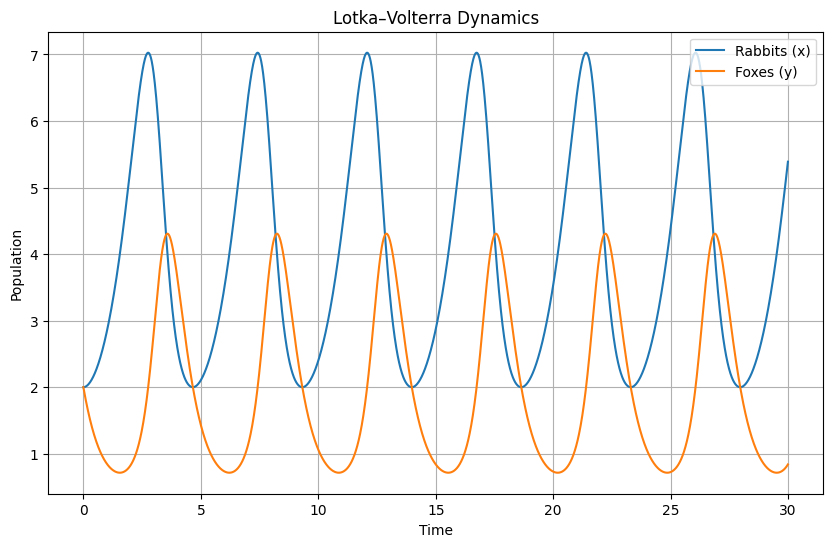

In [ ]:
t, x, y = RK4()

plt.figure(figsize=(10,6))
plt.plot(t, x, label="Rabbits (x)")
plt.plot(t, y, label="Foxes (y)")
plt.xlabel("Time")
plt.ylabel("Population")
plt.legend()
plt.grid()
plt.title("Lotka–Volterra Dynamics")
plt.show()

b)

"x" and "y" → "Rabbits" and "Foxes"

  - Rabbits reproduce at rate proportional to there population and eaten up by foxes at rate proportional to both their population and foxes population.
  - Foxes reproduce at rate proportional to there and rabbits population and dies proportional to their population.

  - For low population of rabbits low value of y, population of foxes also start declining.
  - As population of rabbits inceases, foxes find more food and there population also start increasing.
  - Eventually foxes increases that many in number that they start eating rabbits faster than growth rate of rabbits. So population of rabbits start decresing.
  - Leads to starvation, foxes decreases leads to growth of population of rabbits.
  - Same cycle repeats.

# Exercise 3: The Lorenz Equation

$$\frac{dx}{dt} = \sigma(y-x)$$
$$\frac{dy}{dt} = rx - y - xz$$
$$\frac{dz}{dt} = xy - bz$$

a)
$$\sigma = 10, \, r = 28, \, b = \frac{8}{3}$$

Initial Conditions $(x,y,z) = (0,1,0)$ from t=0 to t = 50

In [ ]:
sigma = 10
r = 28
b = 8/3

def fx(x, y, z):
  return sigma * (y - x)

def fy(x, y, z):
  return r*x - y - x*z

def fz(x, y, z):
  return x*y - b*z

In [ ]:
# RK4 solver
def RK4(h=0.01, t_max=50):
  t_vals = np.arange(0, t_max, h)

  x_vals = np.zeros(len(t_vals))
  y_vals = np.zeros(len(t_vals))
  z_vals = np.zeros(len(t_vals))

  x, y, z = 0, 1, 0

  for i in range(len(t_vals)):
    x_vals[i] = x
    y_vals[i] = y
    z_vals[i] = z

    k1x = fx(x, y, z)
    k1y = fy(x, y, z)
    k1z = fz(x, y, z)

    k2x = fx(x + h*k1x/2, y + h*k1y/2, z + h*k1z/2)
    k2y = fy(x + h*k1x/2, y + h*k1y/2, z + h*k1z/2)
    k2z = fz(x + h*k1x/2, y + h*k1y/2, z + h*k1z/2)

    k3x = fx(x + h*k2x/2, y + h*k2y/2, z + h*k2z/2)
    k3y = fy(x + h*k2x/2, y + h*k2y/2, z + h*k2z/2)
    k3z = fz(x + h*k2x/2, y + h*k2y/2, z + h*k2z/2)

    k4x = fx(x + h*k3x, y + h*k3y, z + h*k3z)
    k4y = fy(x + h*k3x, y + h*k3y, z + h*k3z)
    k4z = fz(x + h*k3x, y + h*k3y, z + h*k3z)

    x += (h/6)*(k1x + 2*k2x + 2*k3x + k4x)
    y += (h/6)*(k1y + 2*k2y + 2*k3y + k4y)
    z += (h/6)*(k1z + 2*k2z + 2*k3z + k4z)

  return t_vals, x_vals, y_vals, z_vals

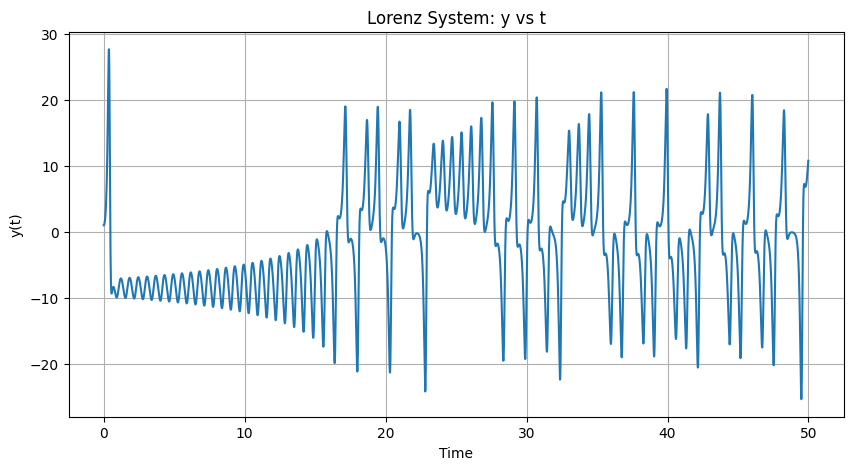

In [ ]:
t, x, y, z = RK4()

plt.figure(figsize=(10,5))
plt.plot(t, y)
plt.xlabel("Time")
plt.ylabel("y(t)")
plt.title("Lorenz System: y vs t")
plt.grid()
plt.show()



b) z vs x: Strange Attractor

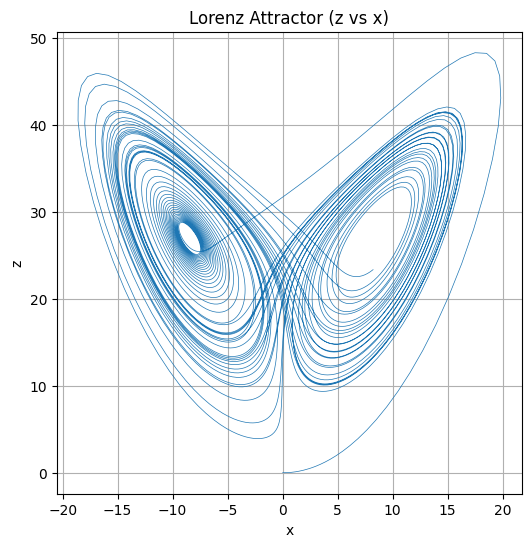

In [ ]:
plt.figure(figsize=(6,6))
plt.plot(x, z, lw=0.5)
plt.xlabel("x")
plt.ylabel("z")
plt.title("Lorenz Attractor (z vs x)")
plt.grid()
plt.show()

# Exercise 4: Harmonic and anharmonic oscillators

\begin{aligned}
\frac{d^2x}{dt^2} &= -\omega ^2 x  \\
\frac{dx}{dt} &= v \\
\frac{dv}{dt} &= -\omega ^2 x
\end{aligned}



a)
$$\omega =1$$ from t = 0 to t =50

Initial Conditions: $x(0) = 1$ and $v(0) = 0$

In [ ]:
omega = 1

def fx(x, v):
  return v

def fv(x, v):
  return -omega**2 * x


In [ ]:
def RK4_oscillator(x0, v0, omega=1, h=0.01, t_max=50):
  t_vals = np.arange(0, t_max, h)
  x_vals = np.zeros(len(t_vals))
  v_vals = np.zeros(len(t_vals))

  x, v = x0, v0 # initial conditions

  for i in range(len(t_vals)):
    x_vals[i] = x
    v_vals[i] = v

    k1x = fx(x,v)
    k1v = fv(x,v)

    k2x = fx(x+h*k1x/2, v+h*k1v/2)
    k2v = fv(x+h*k1x/2, v+h*k1v/2)

    k3x = fx(x+h*k2x/2, v+h*k2v/2)
    k3v = fv(x+h*k2x/2, v+h*k2v/2)

    k4x = fx(x+h*k3x, v+h*k3v)
    k4v = fv(x+h*k3x, v+h*k3v)

    x += (h/6)*(k1x + 2*k2x + 2*k3x + k4x)
    v += (h/6)*(k1v + 2*k2v + 2*k3v + k4v)

  return t_vals, x_vals, v_vals

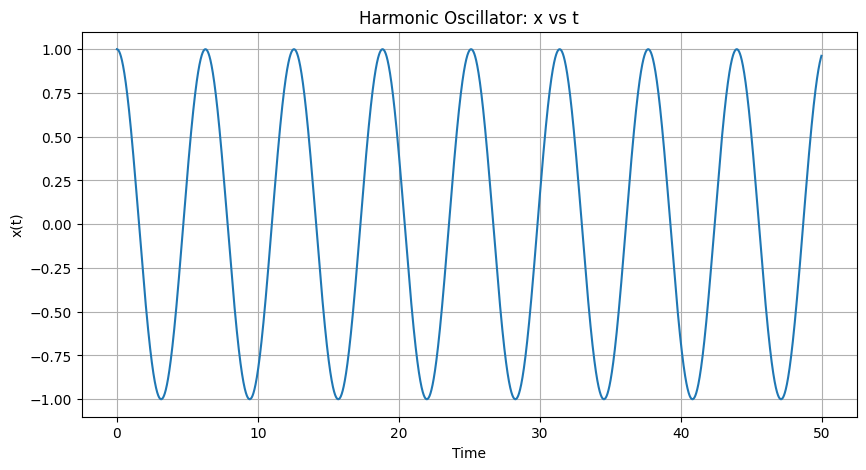

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

t, x, v = RK4_oscillator(x0 = 1, v0 = 0)

plt.figure(figsize=(10,5))
plt.plot(t, x)
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Harmonic Oscillator: x vs t")
plt.grid()
plt.show()

b)
Initial Conditions: $x = 2$ and $dx/dt = 0$

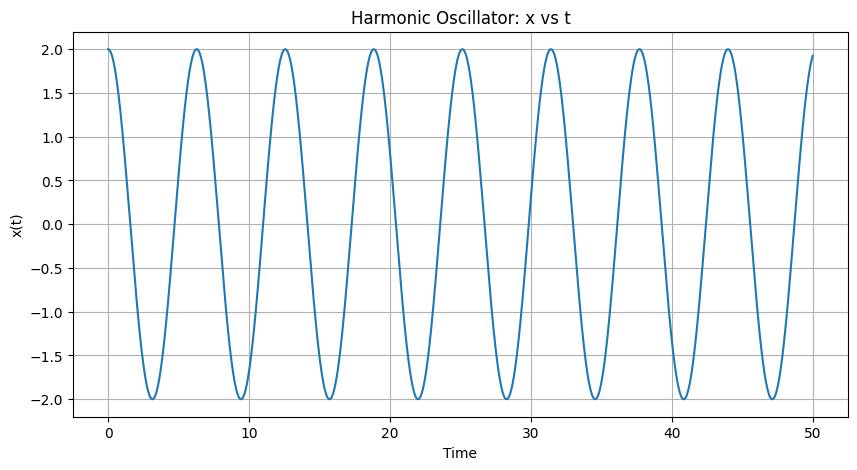

In [ ]:
t, x, v = RK4_oscillator(x0 = 2, v0 = 0)

plt.figure(figsize=(10,5))
plt.plot(t, x)
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Harmonic Oscillator: x vs t")
plt.grid()
plt.show()

Looking to above two figure, then counting number of crest in same time axis:

  - For harmonic oscillator, time period remains same even amplitude of initial condition was increased.

c)
\begin{aligned}
\frac{d^2x}{dt^2} &= -\omega ^2 x^3  \\
\frac{dx}{dt} &= v \\
\frac{dv}{dt} &= -\omega ^2 x^3
\end{aligned}

$\omega =1$

Initial Conditions: $x = 1$ and $dx/dt = 0$

In [ ]:
omega = 1

def fx(x, v):
  return v

def fv(x, v):
  return -omega**2 * x**3


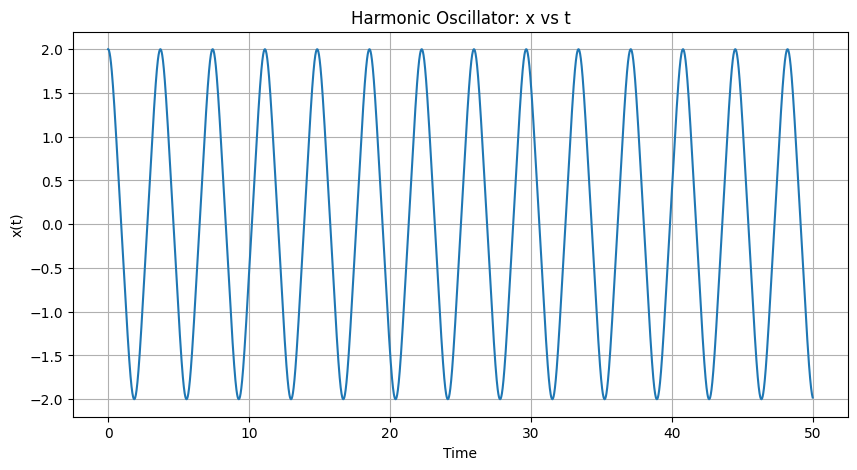

In [ ]:
t, x, v = RK4_oscillator(x0 = 2, v0 = 0)

plt.figure(figsize=(10,5))
plt.plot(t, x)
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Harmonic Oscillator: x vs t")
plt.grid()
plt.show()

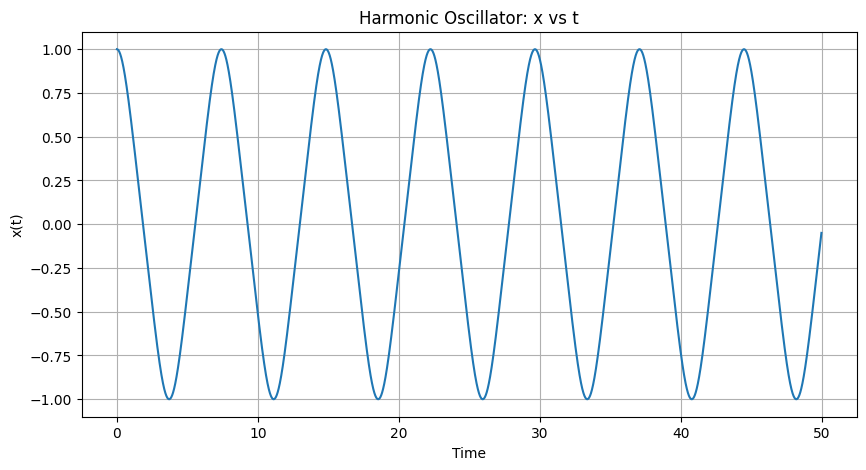

In [ ]:
t, x, v = RK4_oscillator(x0 = 1, v0 = 0)

plt.figure(figsize=(10,5))
plt.plot(t, x)
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Harmonic Oscillator: x vs t")
plt.grid()
plt.show()

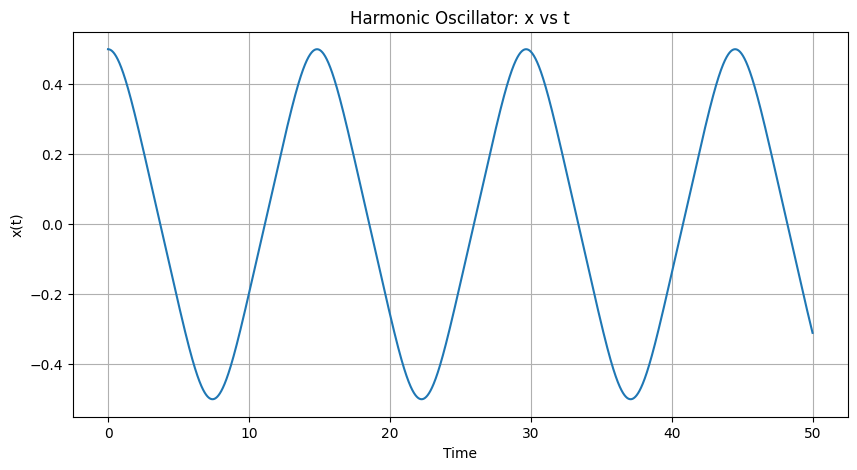

In [ ]:
# Lower Amplitude
t, x, v = RK4_oscillator(x0 = 0.5, v0 = 0)

plt.figure(figsize=(10,5))
plt.plot(t, x)
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Harmonic Oscillator: x vs t")
plt.grid()
plt.show()

For different amplitude in initial condition:
  - Anharmonic Oscillator have different time period as number of crest changes in same time axis.

d)

Harmonic

In [ ]:
omega = 1

def fx(x, v):
  return v

def fv(x, v):
  return -omega**2 * x

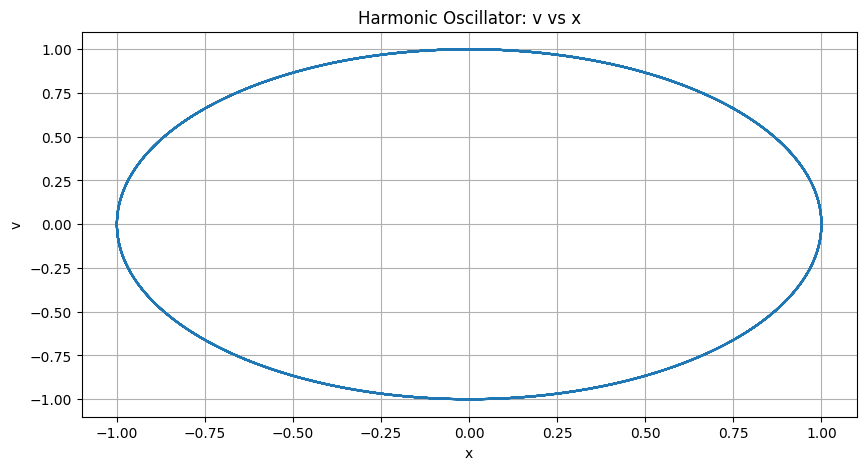

In [ ]:
t, x, v = RK4_oscillator(x0 = 1, v0 = 0)

plt.figure(figsize=(10,5))
plt.plot(x, v)
plt.xlabel("x")
plt.ylabel("v")
plt.title("Harmonic Oscillator: v vs x")
plt.grid()
plt.show()

Anharmonic

In [ ]:
omega = 1

def fx(x, v):
  return v

def fv(x, v):
  return -omega**2 * x**3

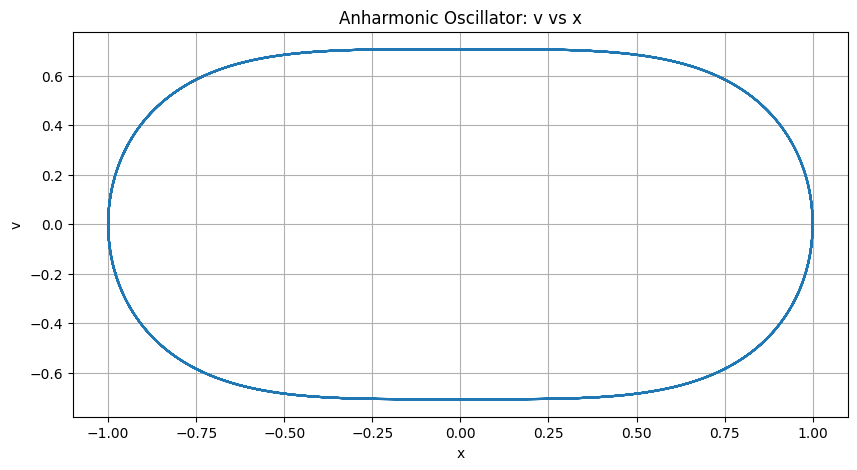

In [ ]:
t, x, v = RK4_oscillator(x0 = 1, v0 = 0)

plt.figure(figsize=(10,5))
plt.plot(x, v)
plt.xlabel("x")
plt.ylabel("v")
plt.title("Anharmonic Oscillator: v vs x")
plt.grid()
plt.show()

e) Van der Pol oscillator

$$\frac{d^2x}{dt^2} - \mu(1-x^2)\frac{dx}{dt} +\omega^2 x = 0 $$

\begin{aligned}
\frac{d^2x}{dt^2} &= \mu(1-x^2)\frac{dx}{dt} -\omega^2 x \\
\implies \frac{dx}{dt} &= v \\
\implies \frac{dv}{dt} &= \mu(1-x^2)v -\omega^2 x
\end{aligned}

t = 0 to t = 20, $\omega = 1 $ and $\mu =1$ and Initial Conditions: $x =1$ and $dx/dt = 0$

In [ ]:
mu = 1
omega = 1

def fx(x, v):
  return v

def fv(x, v):
  return mu*(1-x**2)*v - omega**2 * x

In [ ]:
def RK4_oscillator(x0, v0, omega=1, h=0.01, t_max=20):
  t_vals = np.arange(0, t_max, h)
  x_vals = np.zeros(len(t_vals))
  v_vals = np.zeros(len(t_vals))

  x, v = x0, v0 # initial conditions

  for i in range(len(t_vals)):
    x_vals[i] = x
    v_vals[i] = v

    k1x = fx(x,v)
    k1v = fv(x,v)

    k2x = fx(x+h*k1x/2, v+h*k1v/2)
    k2v = fv(x+h*k1x/2, v+h*k1v/2)

    k3x = fx(x+h*k2x/2, v+h*k2v/2)
    k3v = fv(x+h*k2x/2, v+h*k2v/2)

    k4x = fx(x+h*k3x, v+h*k3v)
    k4v = fv(x+h*k3x, v+h*k3v)

    x += (h/6)*(k1x + 2*k2x + 2*k3x + k4x)
    v += (h/6)*(k1v + 2*k2v + 2*k3v + k4v)

  return t_vals, x_vals, v_vals

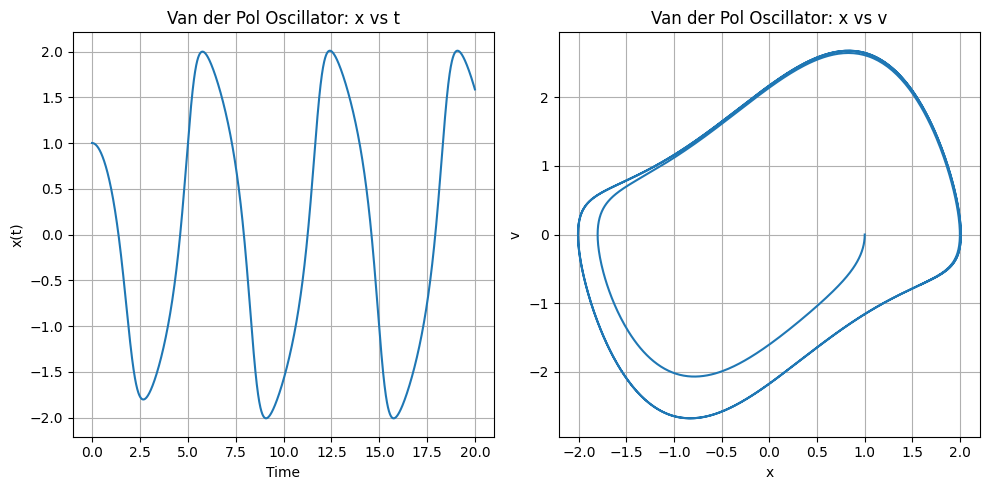

In [ ]:
t, x, v = RK4_oscillator(x0 = 1, v0 = 0)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(t, x)
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Van der Pol Oscillator: x vs t")
plt.grid()

plt.subplot(1,2,2)
plt.plot(x, v)
plt.xlabel("x")
plt.ylabel("v")
plt.title("Van der Pol Oscillator: x vs v")
plt.grid()

plt.tight_layout()
plt.show()

$$\frac{d^2x}{dt^2} - \mu(1-x^2)\frac{dx}{dt} +\omega^2 x = 0$$

t = 0 to t = 20, $\omega = 1 $ and $\mu =2$ and Initial Conditions: $x =1$ and $dx/dt = 0$

In [ ]:
mu = 2
omega = 1

def fx(x, v):
  return v

def fv(x, v):
  return mu*(1-x**2)*v - omega**2 * x

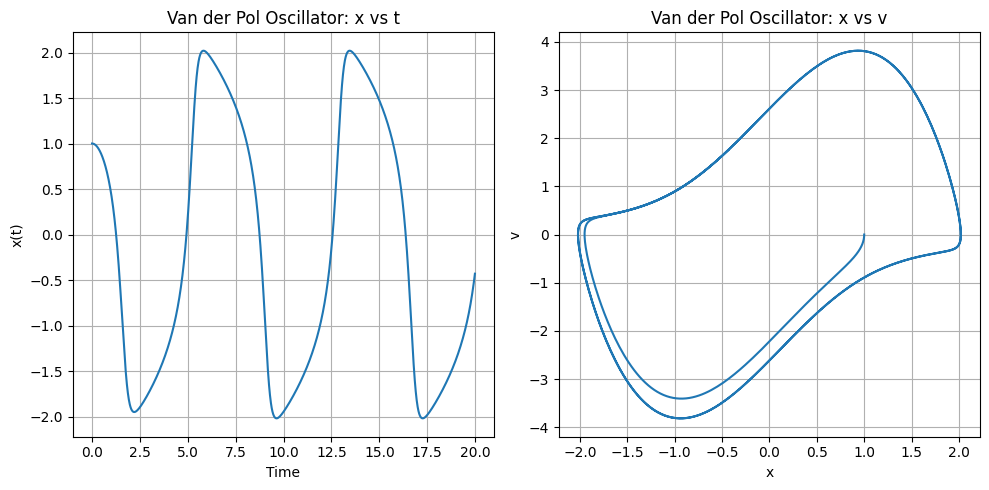

In [ ]:
t, x, v = RK4_oscillator(x0 = 1, v0 = 0)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(t, x)
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Van der Pol Oscillator: x vs t")
plt.grid()

plt.subplot(1,2,2)
plt.plot(x, v)
plt.xlabel("x")
plt.ylabel("v")
plt.title("Van der Pol Oscillator: x vs v")
plt.grid()

plt.tight_layout()
plt.show()

$$\frac{d^2x}{dt^2} - \mu(1-x^2)\frac{dx}{dt} +\omega^2 x = 0$$

t = 0 to t = 2, $\omega = 1 $ and $\mu =4$ and Initial Conditions: $x =1$ and $dx/dt = 0$

In [ ]:
mu = 4
omega = 1

def fx(x, v):
  return v

def fv(x, v):
  return mu*(1-x**2)*v - omega**2 * x

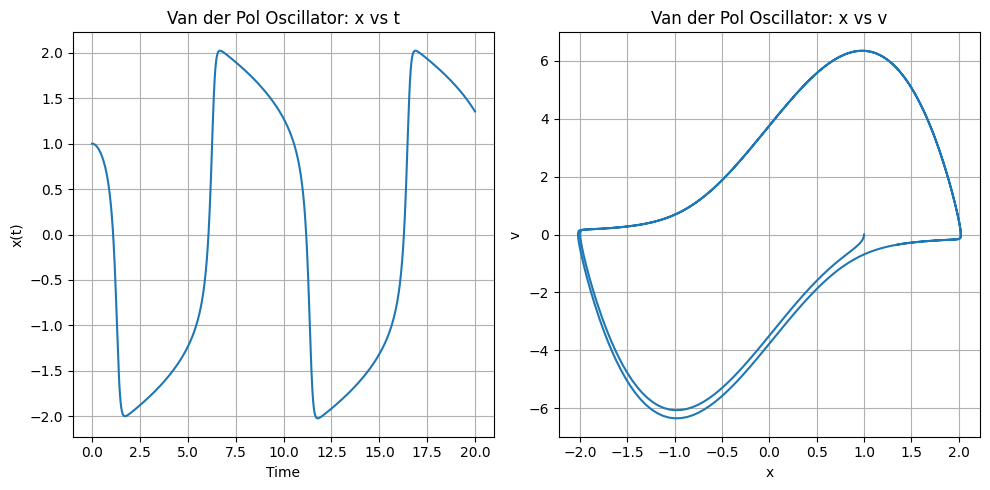

In [ ]:
t, x, v = RK4_oscillator(x0 = 1, v0 = 0)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(t, x)
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Van der Pol Oscillator: x vs t")
plt.grid()

plt.subplot(1,2,2)
plt.plot(x, v)
plt.xlabel("x")
plt.ylabel("v")
plt.title("Van der Pol Oscillator: x vs v")
plt.grid()

plt.tight_layout()
plt.show()

# Exercise 5: Cometary orbits

a)

$$\frac{d^2x}{dt^2} = -GM\frac{\vec{x}}{r^3} $$

$$\boxed{ \frac{dx}{dt} = v_x \\  \frac{dv_x}{dt} = -GM\frac{\vec{x}}{r^3}}$$

$$\frac{d^2y}{dt^2} = -GM\frac{\vec{y}}{r^3}$$

$$\boxed{\frac{dy}{dt} = v_y \\ \frac{dv_y}{dt} = -GM\frac{\vec{y}}{r^3}}$$
where $r = \sqrt{x^2 + y^2}$

b)

In [ ]:
G = 6.6738e-11
M = 1.9891e30

def f(phasespace):
  x, y, vx, vy = phasespace
  r = np.sqrt(x**2 + y**2)
  ax = -G*M*x / r**3
  ay = -G*M*y / r**3
  return np.array([vx, vy, ax, ay])


In [ ]:
def RK4(phasespace, h):
  k1 = f(phasespace)
  k2 = f(phasespace + h*k1/2)
  k3 = f(phasespace + h*k2/2)
  k4 = f(phasespace + h*k3)

  return phasespace + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

Time period of revolution:

Initial conditions: $x = 4 \times 10^{9} km, y = 0km, v_x = 0m/s, v_y = 500m/s \implies \text{perihelion}$

$$T = \frac{2\pi r}{v} = \frac{8 \pi \times 10^{12}}{500} ≈ 5 \times 10^{10}$$

$$\text{2 revolution} \implies 2*T = 10^{11}$$

In [ ]:
import numpy as np

tmax = 1e11
h = 1e4

# initial state
phasespace = np.array([4e12, 0, 0, 500])

traj = []

t = 0
while t < tmax:
  traj.append(phasespace[:2])
  phasespace = RK4(phasespace, h)
  t += h

/tmp/ipykernel_164797/233620724.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


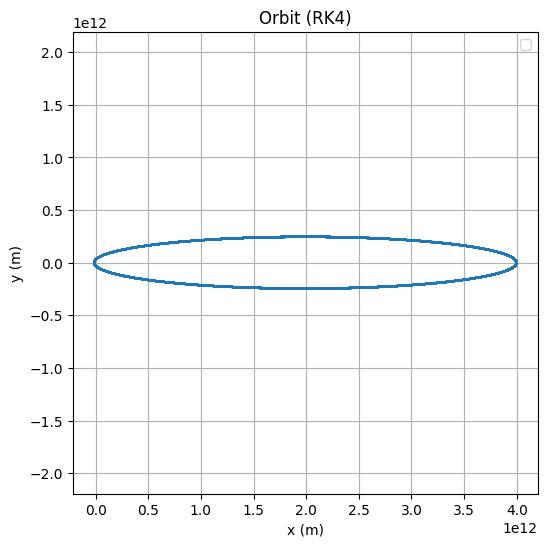

In [ ]:
import matplotlib.pyplot as plt

trajectory = np.array(traj)
x = trajectory[:,0]
y = trajectory[:,1]
plt.figure(figsize=(6,6))
plt.plot(x, y)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Orbit (RK4)")
plt.legend()
plt.axis('equal')
plt.grid()
plt.show()

c)

Adaptive RK4:

$\delta = 1km$

Error between one big step and two small step RK4:
$$\in = ch^5 = \frac{1}{30} (x_1 - x_2)$$

$$\in' = ch'^5 = ch^5 \frac{h'^5}{h^5}= \frac{1}{30} (x_1 - x_2) \frac{h'^5}{h^5} = h' δ$$

$$ h' = h\left(\frac{30h\delta}{|x_1 - x_2|}\right)^{1/4} = h ρ^{1/4}$$

$$\rho = \frac{30h\delta}{|x_1 - x_2|}$$

$h\delta =$ target accuracy and $\frac{1}{30}|x_1 - x_2| =$ actual accuracy for each steps of size h



In [ ]:
def adaptive_RK4(phasespace, h, delta):

  big_phase = RK4(phasespace, 2*h)

  small_phase = RK4(phasespace, h)
  small_phase = RK4(small_phase, h)

  dx = small_phase[0] - big_phase[0]
  dy = small_phase[1] - big_phase[1]
  error = np.sqrt(dx**2 + dy**2)

  if error == 0:
    rho = 2
  else:
    rho = (delta / error)**0.25

  if rho >= 1:
    new_phase = small_phase
    h_new = h * min(rho, 2)
    dt = 2*h
    accepted = True
  else:
    new_phase = phasespace
    h_new = h * max(rho, 0.1)
    dt = 0
    accepted = False

  return new_phase, h_new, dt, accepted

In [ ]:
t = 0
tmax = 1e11
h = 1e5
delta = 1e3

phasespace = np.array([4e12, 0, 0, 500])
traj = []

while t < tmax:
  new_phase, h, dt, accepted = adaptive_RK4(phasespace, h, delta)

  if accepted:
    phasespace = new_phase
    traj.append(phasespace[:2])
    t += dt

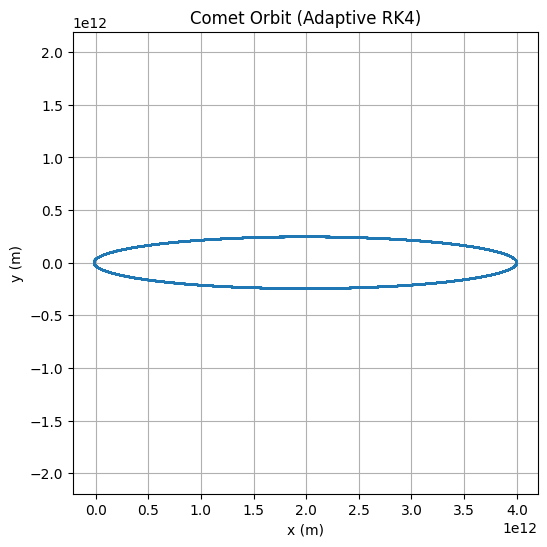

In [ ]:
traj = np.array(traj)

plt.figure(figsize=(6,6))
plt.plot(traj[:,0], traj[:,1])
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Comet Orbit (Adaptive RK4)")
plt.axis("equal")
plt.grid()
plt.show()

Compare adaptive RK4 to RK4:

  - RK4 with single small h value is coputationally expensive as it takes loger time for execution.
  - Adaptive RK4 uses adaptive h value, either perform RK steps over 2h step or multiple RK steps over smaller h values to map rapidly varying function.  

d)

In [ ]:
traj = []

t = 0
prev_y = phasespace[1]

while True:
  new_phase, h, dt, accepted = adaptive_RK4(phasespace, h, delta)

  if accepted:
    phasespace = new_phase
    traj.append(phasespace[:2])
    t += dt

    if phasespace[1] > 0 and prev_y < 0 and t > 1e9:
      break

    prev_y = phasespace[1]

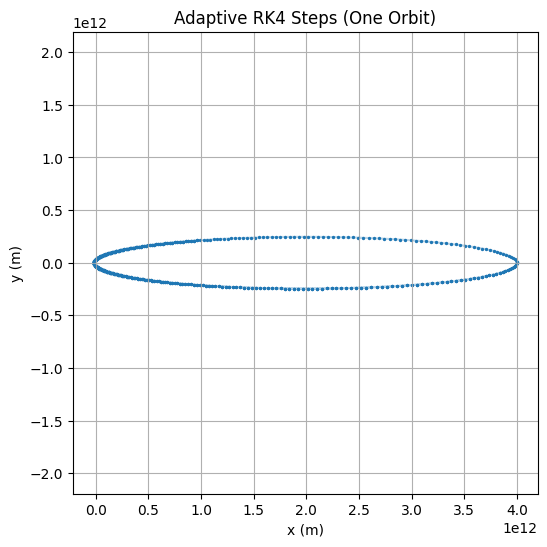

In [ ]:
traj = np.array(traj)

plt.figure(figsize=(6,6))

plt.scatter(traj[:,0], traj[:,1], s=2)

plt.plot(traj[:,0], traj[:,1], alpha=0.3)

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Adaptive RK4 Steps (One Orbit)")
plt.axis("equal")
plt.grid()
plt.show()

Sun at (0,0):

  - Near perihelion dots are densel crowded, gravitational acceleration stronger near the Sun thus smaller time steps is required.
  - Also at apehelion dots are crowded
  - In between dots are more sparse.

# Exercise 6: Orbit of the Earth

$$\frac{d^2r}{dt^2} = -GM\frac{\vec{r}}{r^3}$$

$G = 6.6738 \times 10^{-11} \, m^3kg^{-1}s^{-2}$ and $M = 1.9891 \times 10^{30} kg$

a) Verlet Metod:



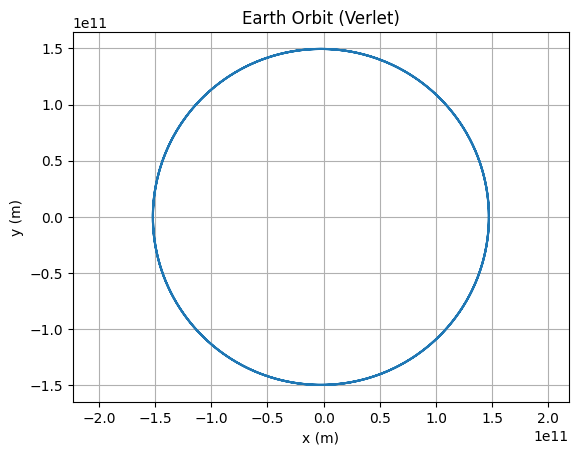

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

G = 6.6738e-11
M = 1.9891e30

def acc(x, y):
  r = np.sqrt(x**2 + y**2)
  ax = -G*M*x / r**3
  ay = -G*M*y / r**3
  return ax, ay

x, y = 1.4710e11, 0
vx, vy = 0, 3.0287e4

h = 3600
tmax = 3 * 365 * 24 * 3600

traj = []

ax, ay = acc(x, y)

t = 0
while t < tmax:
  traj.append([x, y])

  x_new = x + vx*h + 0.5*ax*h**2
  y_new = y + vy*h + 0.5*ay*h**2

  # new acceleration
  ax_new, ay_new = acc(x_new, y_new)

  # velocity update
  vx += 0.5*h*(ax + ax_new)
  vy += 0.5*h*(ay + ay_new)

  # update
  x, y = x_new, y_new
  ax, ay = ax_new, ay_new

  t += h

traj = np.array(traj)

plt.plot(traj[:,0], traj[:,1])
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Earth Orbit (Verlet)")
plt.axis("equal")
plt.grid()
plt.show()

b)

In [ ]:
m = 5.9722e24

x, y = 1.4710e11, 0
vx, vy = 0, 3.0287e4

h = 3600
tmax = 3 * 365 * 24 * 3600

KE_list, PE_list, TE_list, t_list = [], [], [], []

ax, ay = acc(x, y)
t = 0
while t < tmax:
  v = np.sqrt(vx**2 + vy**2)
  r = np.sqrt(x**2 + y**2)

  KE = 0.5*m*v**2
  PE = -G*M*m / r
  TE = KE + PE

  KE_list.append(KE)
  PE_list.append(PE)
  TE_list.append(TE)
  t_list.append(t)

  x_new = x + vx*h + 0.5*ax*h**2
  y_new = y + vy*h + 0.5*ay*h**2

  ax_new, ay_new = acc(x_new, y_new)

  vx += 0.5 * (ax + ax_new) * h
  vy += 0.5 * (ay + ay_new) * h

  x, y = x_new, y_new
  ax, ay = ax_new, ay_new
  t += h

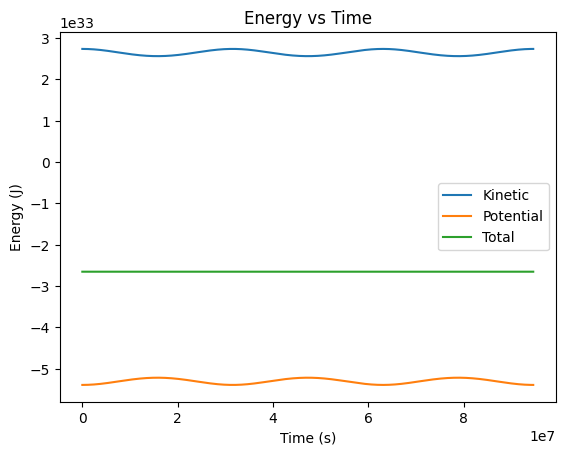

In [ ]:
plt.plot(t_list, KE_list, label="Kinetic")
plt.plot(t_list, PE_list, label="Potential")
plt.plot(t_list, TE_list, label="Total")
plt.xlabel("Time (s)")
plt.ylabel("Energy (J)")
plt.legend()
plt.title("Energy vs Time")
plt.show()

c)

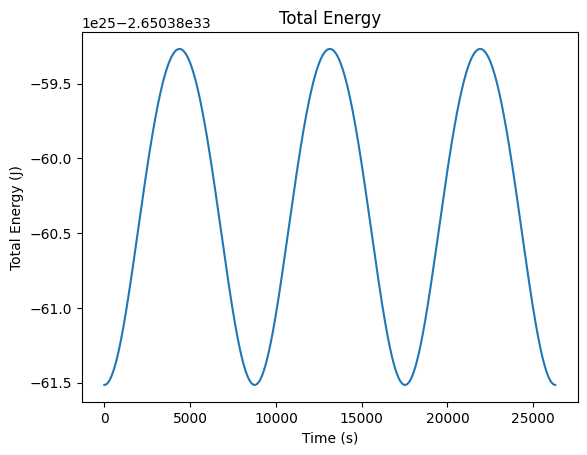

In [ ]:
plt.plot(TE_list)
plt.xlabel("Time (s)")
plt.ylabel("Total Energy (J)")
plt.title("Total Energy")
plt.show()

# Exercise 7: Quantum Oscillators

a)

$$V(x) = V_0 \frac{x^2}{a^2}$$

$V_0 = 50$

$a = 10^{-11}$

$\psi = 0$ at boundaries

$x \in (-10a, 10a)$


SE: $-\frac{ħ^2}{2m} \frac{d^2\psi}{dt^2} + V(x) \psi = E \psi$

$$\implies \frac{d^2\psi}{dx^2} = \frac{2m}{\hbar ^2}(V(x)-E) \psi $$
$$\psi = \psi_1$$
$$\boxed{\frac{d\psi_1}{dx} = \psi_2 \\ \frac{d\psi_2}{dx} = \frac{2m}{\hbar ^2}(V(x)-E) \psi_1}$$

In [9]:
hbar = 1.054e-34
m = 9.109e-31
eV = 1.602e-19

V0 = 50 * eV
a = 1e-11

In [10]:
def V(x):
  return V0 * x**2 / a**2

In [11]:
def f(x, psi, E):
  psi1, psi2 = psi
  dpsi1 = psi2
  dpsi2 = (2*m/hbar**2)*(V(x) - E)*psi1
  return np.array([dpsi1, dpsi2])

In [12]:
def RK4(f, x, psi, h, E):
  k1 = h * f(x, psi, E)
  k2 = h * f(x + h/2, psi + k1/2, E)
  k3 = h * f(x + h/2, psi + k2/2, E)
  k4 = h * f(x + h, psi + k3, E)
  return psi + (k1 + 2*k2 + 2*k3 + k4)/6

In [13]:
def solve_wavefunction(E, width):
  x_vals = np.linspace(-width, width, 1000)
  h = x_vals[1] - x_vals[0]

  psi = np.array([0.0, 1e-5])
  psi_vals = []

  for x in x_vals:
    psi_vals.append(psi[0])
    psi = RK4(f, x, psi, h, E)

  return x_vals, np.array(psi_vals)

Bisection method to get eigenvalue energy

$\psi(-10a) = \psi(10a) = 0,$ for eigenvalue energy:
  
  - Thus $\psi$ other than eigenvlue energy at boundary is either $\gt$ or $\lt$ 0  
  -  Using bisection method to finf E

In [14]:
def find_energy(E1, E2, width, tol=1e-6, max_iter=100):

  xm, psi1 = solve_wavefunction(E1, width)
  xm, psi2 = solve_wavefunction(E2, width)

  if psi1[-1] * psi2[-1] > 0:
    raise ValueError("E1 and E2 do NOT bracket a root")

  for _ in range(max_iter):

    Em = 0.5 * (E1 + E2)
    xm, psim = solve_wavefunction(Em, width)

    if abs(psim[-1]) < tol:
      return Em

    if psi1[-1] * psim[-1] < 0:
      E2 = Em
      psi2 = psim
    else:
      E1 = Em
      psi1 = psim

    return 0.5 * (E1 + E2)

Scanning energies to find wavefunctions at end points to identify brackets of energy

In [15]:
def scan_energies(E_min, E_max, width, n=200):
  energies = np.linspace(E_min, E_max, n)
  values = []

  for E in energies:
    _, psi = solve_wavefunction(E, width)
    values.append(psi[-1])

  return energies, values

In [16]:
import numpy as np

energies, values = scan_energies(0, 1200*eV, 10*a)

brackets = []
for i in range(len(energies)-1):
  if values[i] * values[i+1] < 0:
    brackets.append((energies[i], energies[i+1]))

print(brackets)

[(np.float64(2.1252663316582915e-17), np.float64(2.2218693467336684e-17)), (np.float64(6.569005025125628e-17), np.float64(6.665608040201005e-17)), (np.float64(1.1012743718592964e-16), np.float64(1.1109346733668342e-16)), (np.float64(1.5456482412060302e-16), np.float64(1.555308542713568e-16))]


Using these brackets in `find_energy`

In [17]:
E0 = find_energy(*brackets[0], width=10*a)
print("Ground state:", E0/eV, "eV")

Ground state: 137.18592964824123 eV


In [18]:
E1 = find_energy(*brackets[1], width=10*a)
print("First ES:", E1/eV, "eV")

First ES: 413.06532663316585 eV


In [19]:
E2 = find_energy(*brackets[2], width=10*a)
print("Ground state:", E2/eV, "eV")

Ground state: 690.4522613065327 eV


In [20]:
print("1st Excited state - Ground state:", (E1 -E0)/eV , "eV")
print("2nd excited state - 1st excited state:", (E2 - E1)/eV, "eV")

1st Excited state - Ground state: 275.87939698492465 eV
2nd excited state - 1st excited state: 277.3869346733668 eV


Approximately, equispaced energy  levels are found.

b)

$$V(x) = V_0 \frac{x^4}{a^2}$$

In [21]:
def V(x):
  return V0 * x**4 / a**2

In [22]:
energies, values = scan_energies(0, 1200*eV, 10*a)

brackets = []
for i in range(len(energies)-1):
  if values[i] * values[i+1] < 0:
    brackets.append((energies[i], energies[i+1]))

print(brackets)

[(np.float64(9.660301507537689e-19), np.float64(1.9320603015075377e-18)), (np.float64(5.796180904522613e-18), np.float64(6.762211055276382e-18)), (np.float64(1.3524422110552764e-17), np.float64(1.4490452261306533e-17)), (np.float64(2.3184723618090453e-17), np.float64(2.415075376884422e-17)), (np.float64(3.6709145728643217e-17), np.float64(3.767517587939699e-17)), (np.float64(5.4097688442211056e-17), np.float64(5.506371859296482e-17)), (np.float64(7.341829145728643e-17), np.float64(7.43843216080402e-17)), (np.float64(9.563698492462312e-17), np.float64(9.660301507537689e-17)), (np.float64(1.2171979899497488e-16), np.float64(1.2268582914572864e-16)), (np.float64(1.4973467336683418e-16), np.float64(1.5070070351758795e-16)), (np.float64(1.8161366834170856e-16), np.float64(1.825796984924623e-16))]


In [23]:
E0 = find_energy(*brackets[0], width=10*a)
print("Ground state:", E0/eV, "eV")

Ground state: 9.045226130653267 eV


In [24]:
E1 = find_energy(*brackets[1], width=10*a)
print("First ES:", E1/eV, "eV")

First ES: 39.19597989949749 eV


In [25]:
E2 = find_energy(*brackets[2], width=10*a)
print("Second state:", E2/eV, "eV")

Second state: 87.43718592964824 eV


Energy level are not equispaced here.

c)

$x \in (-5a, 5a)$



In [26]:
energies, values = scan_energies(0, 1200*eV, 5*a)

brackets = []
for i in range(len(energies)-1):
  if values[i] * values[i+1] < 0:
    brackets.append((energies[i], energies[i+1]))

print(brackets)

[(np.float64(5.796180904522613e-18), np.float64(6.762211055276382e-18)), (np.float64(2.3184723618090453e-17), np.float64(2.415075376884422e-17)), (np.float64(5.4097688442211056e-17), np.float64(5.506371859296482e-17)), (np.float64(9.563698492462312e-17), np.float64(9.660301507537689e-17)), (np.float64(1.4973467336683418e-16), np.float64(1.5070070351758795e-16))]


In [27]:
E0 = find_energy(*brackets[0], width=10*a)
print("Ground state:", E0/eV, "eV")

Ground state: 39.19597989949749 eV


In [28]:
E1 = find_energy(*brackets[1], width=10*a)
print("First ES:", E1/eV, "eV")

First ES: 147.73869346733667 eV


In [29]:
E2 = find_energy(*brackets[2], width=10*a)
print("Second state:", E2/eV, "eV")

Second state: 340.7035175879397 eV


Using symmetric property of system

In [30]:
def normalize(x, psi):
  dx = x[1] - x[0]
  integral = 2*np.sum(psi**2)*dx
  return psi / np.sqrt(integral)

In [31]:
x_plot, psi0_unnorm = solve_wavefunction(E0, width = 5*a)
psi0 = normalize(x_plot, psi0_unnorm)

_, psi1_unnorm = solve_wavefunction(E1, width = 5*a)
psi1 = normalize(x_plot, psi1_unnorm)

_, psi2_unnorm = solve_wavefunction(E2, width = 5*a)
psi2 = normalize(x_plot, psi2_unnorm)

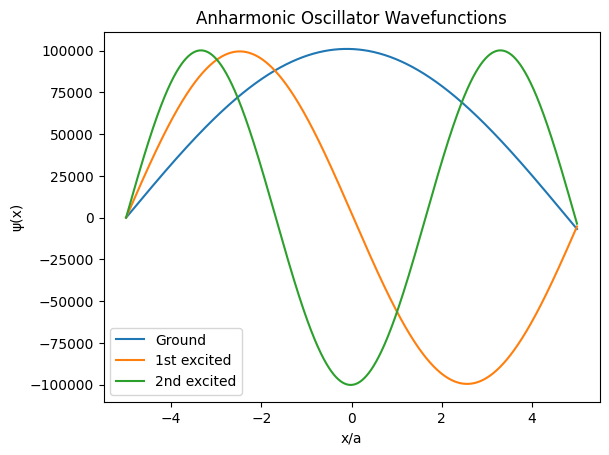

In [32]:
import matplotlib.pyplot as plt

plt.plot(x_plot/a, psi0, label="Ground")
plt.plot(x_plot/a, psi1, label="1st excited")
plt.plot(x_plot/a, psi2, label="2nd excited")
plt.legend()
plt.xlabel("x/a")
plt.ylabel("ψ(x)")
plt.title("Anharmonic Oscillator Wavefunctions")
plt.show()

# Exercise 8: The three-body problem

$$
\begin{array}{c|cc}
\hline
 & Mass & x & y\\
\hline
Star 1 & 150 & 3 & 1\\
Star 2 & 200 & -1 & 2\\
Star 3 & 250 & -1 & 1\\
\hline
\end{array}
$$

a)

$$ \frac{d^2r_1}{dt^2} = Gm_2\frac{\vec{r_2} - \vec{r_1}}{|r_2 - r_1|} + Gm_3\frac{\vec{r_3} - \vec{r_1}}{|r_3 - r_1|}$$

$$ \frac{d^2r_2}{dt^2} = Gm_3\frac{\vec{r_3} - \vec{r_2}}{|r_3 - r_2|} + Gm_1\frac{\vec{r_1} - \vec{r_2}}{|r_1 - r_2|}$$

$$ \frac{d^2r_3}{dt^2} = Gm_1\frac{\vec{r_1} - \vec{r_3}}{|r_1 - r_3|} + Gm_2\frac{\vec{r_1} - \vec{r_3}}{|r_1 - r_3|}$$


Define:

$v_i = \frac{dr_i}{dt}$

$$\boxed{v_1 = \frac{dr_1}{dt}, \,\,\,\, \frac{dv_1}{dt} = Gm_2\frac{\vec{r_2} - \vec{r_1}}{|r_2 - r_1|} + Gm_3\frac{\vec{r_3} - \vec{r_1}}{|r_3 - r_1|}}$$

$$\boxed{v_2 = \frac{dr_2}{dt}, \,\,\,\, \frac{dv_2}{dt} = Gm_3\frac{\vec{r_3} - \vec{r_2}}{|r_3 - r_2|} + Gm_1\frac{\vec{r_1} - \vec{r_2}}{|r_1 - r_2|}}$$

$$\boxed{v_3 = \frac{dr_3}{dt}, \,\,\,\, \frac{dv_3}{dt} = Gm_1\frac{\vec{r_1} - \vec{r_3}}{|r_1 - r_3|} + Gm_2\frac{\vec{r_1} - \vec{r_3}}{|r_1 - r_3|}}$$

b)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

G = 1.0
m1, m2, m3 = 150, 200, 250

eps = 1e-5

def acceleration(r1, r2, r3):

  def force(ri, rj, mj):
    diff = rj - ri
    dist = np.linalg.norm(diff) + eps
    return G * mj * diff / dist**3

  a1 = force(r1, r2, m2) + force(r1, r3, m3)
  a2 = force(r2, r1, m1) + force(r2, r3, m3)
  a3 = force(r3, r1, m1) + force(r3, r2, m2)

  return a1, a2, a3

In [ ]:
def derivatives(phasespace):

  r1 = phasespace[0:2]
  r2 = phasespace[2:4]
  r3 = phasespace[4:6]

  v1 = phasespace[6:8]
  v2 = phasespace[8:10]
  v3 = phasespace[10:12]

  a1, a2, a3 = acceleration(r1, r2, r3)

  return np.concatenate([v1, v2, v3, a1, a2, a3])

In [ ]:
def RK4(phasespace, h):

  k1 = derivatives(phasespace)
  k2 = derivatives(phasespace + 0.5*h*k1)
  k3 = derivatives(phasespace + 0.5*h*k2)
  k4 = derivatives(phasespace + h*k3)

  return phasespace + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

In [ ]:
def adaptive_RK4(phasespace, h, delta):

  big = RK4(phasespace, 2*h)

  small = RK4(phasespace, h)
  small = RK4(small, h)

  error = np.linalg.norm(small - big)

  error_per_time = error / (2*h)

  if error_per_time == 0:
    rho = 2
  else:
    rho = (delta / error_per_time)**0.25

  if rho >= 1:
    new_phasespace = small
    dt = 2*h
    h_new = h * min(rho, 2)
    accepted = True
  else:
    new_phasespace = phasespace
    dt = 0
    h_new = h * max(rho, 0.1)
    accepted = False

  return new_phasespace, h_new, dt, accepted

In [ ]:
phasespace = np.array([
    3.0, 1.0,     # r1
   -1.0,-2.0,     # r2
   -1.0, 1.0,     # r3
    0.0, 0.0,     # v1
    0.0, 0.0,     # v2
    0.0, 0.0      # v3
])

In [ ]:
t = 0
t_end = 2

h = 0.01
delta = 1e-3

traj1, traj2, traj3 = [], [], []

while t < t_end:

  traj1.append(phasespace[0:2].copy())
  traj2.append(phasespace[2:4].copy())
  traj3.append(phasespace[4:6].copy())

  new_phasespace, h_new, dt, accepted = adaptive_RK4(phasespace, h, delta)

  if accepted:
    phasespace = new_phasespace
    t += dt

  h = h_new

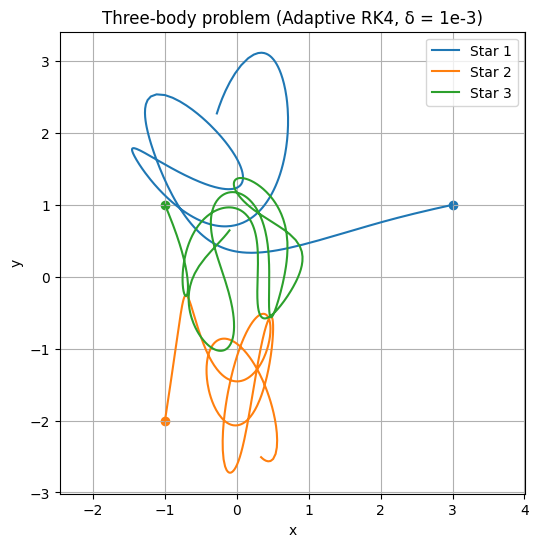

In [ ]:
traj1 = np.array(traj1)
traj2 = np.array(traj2)
traj3 = np.array(traj3)

plt.figure(figsize=(6,6))

plt.plot(traj1[:,0], traj1[:,1], label="Star 1")
plt.plot(traj2[:,0], traj2[:,1], label="Star 2")
plt.plot(traj3[:,0], traj3[:,1], label="Star 3")

plt.scatter(traj1[0,0], traj1[0,1])
plt.scatter(traj2[0,0], traj2[0,1])
plt.scatter(traj3[0,0], traj3[0,1])

plt.xlabel("x")
plt.ylabel("y")
plt.title("Three-body problem (Adaptive RK4, δ = 1e-3)")
plt.legend()
plt.axis('equal')
plt.grid()

plt.show()